In [1]:
import os
import glob
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, lfilter, iirnotch

# ==========================================
# 1. Myo-Specific Signal Filtering 
# ==========================================
def apply_myo_filters(emg_data, fs=200.0):
    """
    Applies Notch and Bandpass filters specifically tuned for Myo Armband (200Hz).
    """
    # 1. Notch Filter (50 Hz) to remove power line interference
    w0 = 50.0 / (fs / 2.0)
    Q = 30.0
    b_notch, a_notch = iirnotch(w0, Q)
    emg_filtered = lfilter(b_notch, a_notch, emg_data, axis=0)
    
    # 2. Bandpass Filter (20-90 Hz) 
    # 90Hz is the safe upper limit for 200Hz sampling rate (Nyquist = 100Hz)
    low = 20.0 / (fs / 2.0)
    high = 90.0 / (fs / 2.0)
    b_band, a_band = butter(4, [low, high], btype='band')
    emg_filtered = lfilter(b_band, a_band, emg_filtered, axis=0)
    
    return emg_filtered

# ==========================================
# 2. Windowing & Data Loading
# ==========================================
def extract_windows(emg, label, window_size, step):
    windows, labels = [], []
    for i in range(0, len(emg) - window_size, step):
        window = emg[i:i + window_size]
        win_label = np.bincount(label[i:i + window_size].flatten()).argmax()
        windows.append(window)
        labels.append(win_label)
    return np.array(windows), np.array(labels)

def load_ninapro_task(base_path, allowed_classes, subjects, allowed_reps, window_size=200, step=20, num_channels=8):
    all_x, all_y = [], []
    for subj in subjects:
        search_pattern = os.path.join(base_path, '**', f'S{subj}_E2*.mat')
        file_paths = glob.glob(search_pattern, recursive=True)
        for file_path in file_paths:
            try:
                data = sio.loadmat(file_path)
                emg = data['emg'][:, :num_channels]
                labels = data['restimulus'].flatten()
                reps = data['repetition'].flatten()
                
                
                emg = apply_myo_filters(emg, fs=200.0)
                
                unique_reps = np.unique(reps)
                for r in unique_reps:
                    if r not in allowed_reps:
                        continue
                    for c in allowed_classes:
                        segment_mask = (labels == c) & (reps == r)
                        if not np.any(segment_mask):
                            continue
                        segment_emg = emg[segment_mask]
                        segment_label = labels[segment_mask]
                        if len(segment_emg) >= window_size:
                            x_wins, y_wins = extract_windows(segment_emg, segment_label, window_size, step)
                            all_x.append(x_wins)
                            all_y.append(y_wins)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    if not all_x:
        return np.array([]), np.array([])

    X = np.concatenate(all_x, axis=0)
    Y = np.concatenate(all_y, axis=0).astype(np.int64)
    return X, Y

def balance_classes(X, Y):
    """موازنة فئة الراحة (0) مع متوسط باقي الفئات"""
    classes, counts = np.unique(Y, return_counts=True)
    print(f"  Before Balancing : {dict(zip(classes, counts))}")
    rest_idx = np.where(Y == 0)[0]
    move_idx = np.where(Y != 0)[0]
    if len(move_idx) > 0 and len(rest_idx) > 0:
        target_rest = int(np.mean([c for cls, c in zip(classes, counts) if cls != 0]))
        if len(rest_idx) > target_rest:
            np.random.seed(42)
            sel_rest = np.random.choice(rest_idx, target_rest, replace=False)
            final_idx = np.concatenate([sel_rest, move_idx])
            np.random.shuffle(final_idx)
            X, Y = X[final_idx], Y[final_idx]
            nc, ncounts = np.unique(Y, return_counts=True)
            print(f"  After Balancing : {dict(zip(nc, ncounts))}")
    return X, Y

# ==========================================
# 3. Data Splitting & Scaling (Preventing Data Leakage)
# ==========================================
TRAIN_DIR = '/kaggle/input/datasets/farahhassanellaban/ninapro-9-subjects'
TARGET_DIR = '/kaggle/input/datasets/farahhassanellaban/test-subject'

PRETRAIN_SUBJECTS = [1, 2, 3, 4, 5, 6, 7, 8, 9]
TARGET_SUBJECT = [10]

# --- بيانات الـ Pretrain ---
print("Loading Pretrain Data (9 subjects, all classes)...")
X_pre_train, Y_pre_train = load_ninapro_task(TRAIN_DIR, [0,1,2,3,4,5], PRETRAIN_SUBJECTS, [1,3,4,6])
X_pre_val,   Y_pre_val   = load_ninapro_task(TRAIN_DIR, [0,1,2,3,4,5], PRETRAIN_SUBJECTS, [2,5])

X_pre_train, Y_pre_train = balance_classes(X_pre_train, Y_pre_train)
X_pre_val,   Y_pre_val   = balance_classes(X_pre_val, Y_pre_val)

pre_scaler = StandardScaler()
B, W, C = X_pre_train.shape
X_pre_train_s = pre_scaler.fit_transform(X_pre_train.reshape(-1, C)).reshape(B, W, C)

Bv, Wv, Cv = X_pre_val.shape
X_pre_val_s = pre_scaler.transform(X_pre_val.reshape(-1, Cv)).reshape(Bv, Wv, Cv)

pretrain_loader = DataLoader(TensorDataset(torch.tensor(X_pre_train_s, dtype=torch.float32), torch.tensor(Y_pre_train)), batch_size=64, shuffle=True)
pretrain_val_loader = DataLoader(TensorDataset(torch.tensor(X_pre_val_s, dtype=torch.float32), torch.tensor(Y_pre_val)), batch_size=64, shuffle=False)

# --- بيانات Subject 10 ---
print("\nLoading Subject 10 - Task 1 (0,1,2) raw windows...")
X_t1_train_raw, Y_t1_train = load_ninapro_task(TARGET_DIR, [0,1,2], TARGET_SUBJECT, [1,3,4,6], step=10)
X_t1_test_raw,  Y_t1_test  = load_ninapro_task(TARGET_DIR, [0,1,2], TARGET_SUBJECT, [2,5], step=10)

print("Loading Subject 10 - Task 2 (0,3,4,5) raw windows...")
X_t2_train_raw, Y_t2_train = load_ninapro_task(TARGET_DIR, [0,3,4,5], TARGET_SUBJECT, [1,3,4,6], step=10)
X_t2_test_raw,  Y_t2_test  = load_ninapro_task(TARGET_DIR, [0,3,4,5], TARGET_SUBJECT, [2,5], step=10)

X_t1_train_raw, Y_t1_train = balance_classes(X_t1_train_raw, Y_t1_train)
X_t2_train_raw, Y_t2_train = balance_classes(X_t2_train_raw, Y_t2_train)


subject_scaler = StandardScaler()
B, W, C = X_t1_train_raw.shape
X_t1_train = subject_scaler.fit_transform(X_t1_train_raw.reshape(-1, C)).reshape(B, W, C)

def apply_scaler(X_raw, scaler):
    b, w, c = X_raw.shape
    return scaler.transform(X_raw.reshape(-1, c)).reshape(b, w, c)

X_t1_test = apply_scaler(X_t1_test_raw, subject_scaler)
X_t2_train = apply_scaler(X_t2_train_raw, subject_scaler)
X_t2_test  = apply_scaler(X_t2_test_raw, subject_scaler)

def make_loader(X, Y, batch_size=64, shuffle=True):
    return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.long)), batch_size=batch_size, shuffle=shuffle)

t1_train_loader = make_loader(X_t1_train, Y_t1_train)
t1_test_loader  = make_loader(X_t1_test, Y_t1_test, shuffle=False)
t2_train_loader = make_loader(X_t2_train, Y_t2_train)
t2_test_loader  = make_loader(X_t2_test, Y_t2_test, shuffle=False)

print("\n Data Loading & Preprocessing Cell Completed Successfully!")

Loading Pretrain Data (9 subjects, all classes)...
  Before Balancing : {np.int64(0): np.int64(14227), np.int64(1): np.int64(1136), np.int64(2): np.int64(908), np.int64(3): np.int64(912), np.int64(4): np.int64(976), np.int64(5): np.int64(814)}
  After Balancing : {np.int64(0): np.int64(949), np.int64(1): np.int64(1136), np.int64(2): np.int64(908), np.int64(3): np.int64(912), np.int64(4): np.int64(976), np.int64(5): np.int64(814)}
  Before Balancing : {np.int64(0): np.int64(7200), np.int64(1): np.int64(568), np.int64(2): np.int64(438), np.int64(3): np.int64(477), np.int64(4): np.int64(460), np.int64(5): np.int64(412)}
  After Balancing : {np.int64(0): np.int64(471), np.int64(1): np.int64(568), np.int64(2): np.int64(438), np.int64(3): np.int64(477), np.int64(4): np.int64(460), np.int64(5): np.int64(412)}

Loading Subject 10 - Task 1 (0,1,2) raw windows...
Loading Subject 10 - Task 2 (0,3,4,5) raw windows...
  Before Balancing : {np.int64(0): np.int64(3293), np.int64(1): np.int64(252), np

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =====================================================================
# 1. Channel Attention Module (Focuses on important frequency/feature maps)
# =====================================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out) * x

# =====================================================================
# 2. Spatial Attention Module (Focuses on relationships between sensors)
# =====================================================================
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        # قللنا الـ kernel_size لـ 3 عشان يناسب الأبعاد الجديدة بعد الـ MaxPool
        self.conv = nn.Conv2d(2, 1, 3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out) * x

# =====================================================================
# 3. Temporal Attention (Focuses on the most important time step)
# =====================================================================
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, gru_output):
        attention_weights = self.attention(gru_output)
        attention_weights = F.softmax(attention_weights, dim=1)
        context_vector = torch.sum(attention_weights * gru_output, dim=1)
        return context_vector

class Metric_ContinualNet(nn.Module):
    def __init__(self, embedding_dim=32, num_sensors=8, window_size=200):
        super(Metric_ContinualNet, self).__init__()
        
        # --- Shared Backbone (الجذع المشترك اللي أثبت كفاءته) ---
        self.temporal_filter = nn.Conv2d(1, 16, kernel_size=(1, 15), stride=(1, 2), padding=(0, 7))
        self.bn_temp = nn.BatchNorm2d(16)
        
        self.depthwise = nn.Conv2d(16, 32, kernel_size=(3, 3), padding=0, groups=16)
        self.pointwise = nn.Conv2d(32, 32, kernel_size=1)
        self.bn_spat = nn.BatchNorm2d(32)
        
        self.ca = ChannelAttention(32)
        self.sa = SpatialAttention()
        
        self.pool = nn.MaxPool2d(kernel_size=(2, 4))
        self.dropout = nn.Dropout(0.3)
        
        gru_input_dim = 32 * 4 
        
        self.gru = nn.GRU(
            input_size=gru_input_dim, 
            hidden_size=64, 
            num_layers=2, 
            batch_first=True,
            dropout=0.3
        )
        self.temporal_attention = TemporalAttention(64)
        
        # --- الرأس الأول: استخراج البصمة (Metric Embedding Head) ---
        # لاحظي إن مفيش عدد كلاسات هنا، البصمة بتطلع كـ Vector
        self.embedding_head = nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, embedding_dim)
        )
        
        # --- الرأس الثاني: النعومة وقوة الحركة (Continuous Regression) ---
        self.regression_head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x, return_intermediate=False):
        B, W, S = x.shape
        x = x.permute(0, 2, 1).contiguous()
        x = x.unsqueeze(1)
    
        x = F.relu(self.bn_temp(self.temporal_filter(x)))
        x = F.pad(x, (1, 1, 0, 0), mode='constant', value=0) 
        x = F.pad(x, (0, 0, 1, 1), mode='circular')          
    
        x = self.depthwise(x)
        x = F.relu(self.bn_spat(self.pointwise(x)))
        x = self.ca(x)
        x = self.sa(x)
    
        x = self.pool(x)
        x = self.dropout(x)
    
        B, C, S_new, T_new = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, T_new, C * S_new)
    
        gru_out, _ = self.gru(x)
        features = self.temporal_attention(gru_out)
    
    #  استخراج features وسيطة (قبل الـ embedding_head)
        intermediate_features = features  # Shape: (B, 64)
    
        embeddings = self.embedding_head(features)
        embeddings = F.normalize(embeddings, p=2, dim=1) 
    
        force = self.regression_head(features)
    
        if return_intermediate:
            return embeddings, force, intermediate_features
        return embeddings, force
    

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# ==========================================
# 1. Supervised Contrastive Loss (SupCon)
# ==========================================
class SupConLoss(nn.Module):
    """Robust Supervised Contrastive Loss"""
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        features = F.normalize(features, p=2, dim=1)
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)
        
        mask = torch.eq(labels, labels.T).float().to(device)
        anchor_dot_contrast = torch.div(torch.matmul(features, features.T), self.temperature)
        
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()
        
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(batch_size, device=device).view(-1, 1), 0)
        mask = mask * logits_mask
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)
        loss = -mean_log_prob_pos
        
        valid_mask = (mask.sum(1) > 0)
        return loss[valid_mask].mean() if valid_mask.sum() > 0 else loss.mean()

# ==========================================
# 2. Helper: Calculate Validation Accuracy (Prototype-based)
# ==========================================
def calculate_val_accuracy(model, val_loader, device='cuda'):
    """Calculates accuracy on validation set using nearest prototype."""
    model.eval()
    all_embs, all_labels = [], []
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            embs, _ = model(x)
            all_embs.append(embs.cpu())
            all_labels.append(y.cpu())
            
    all_embs = torch.cat(all_embs).to(device)
    all_labels = torch.cat(all_labels).to(device)
    
    unique_labels = torch.unique(all_labels)
    protos = torch.stack([all_embs[all_labels == lbl].mean(0) for lbl in unique_labels])
    protos = F.normalize(protos, p=2, dim=1)
    
    dists = torch.cdist(all_embs, protos)
    preds = unique_labels[dists.argmin(1)]
    
    acc = (preds == all_labels).float().mean().item() * 100
    return acc

# ==========================================
# 3. Main Training Function (with Augmentation, Early Stopping & Full Logging)
# ==========================================
def train_metric_learning(model, train_loader, val_loader, epochs=30, lr=0.001, device='cuda', patience=7):
    """
    Training with Data Augmentation, Early Stopping, and Full Logging.
    
    Args:
        patience: Number of epochs to wait for improvement before stopping (default: 7)
    """
    criterion_metric = SupConLoss(temperature=0.07)
    criterion_reg = nn.MSELoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    print("\n" + "="*70)
    print(" Starting Advanced Metric Learning (SupCon + Augmentation + Early Stopping)")
    print("="*70)
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0  # عداد الـ Early Stopping
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        train_samples = 0
        
        # --- Training Loop ---
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Data Augmentation (مهم جداً للـ Myo)
            warp_factor = torch.empty(inputs.shape[0], 1, inputs.shape[2]).uniform_(0.8, 1.2).to(device)
            augmented_inputs = inputs * warp_factor
            noise = torch.randn_like(augmented_inputs) * 0.01
            augmented_inputs = augmented_inputs + noise
            
            actual_force = augmented_inputs.abs().mean(dim=(1,2)).unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            
            # Forward pass on augmented data
            embeddings, predicted_force = model(augmented_inputs)
            
            # Losses
            loss_metric = criterion_metric(embeddings, labels)
            loss_reg = criterion_reg(predicted_force, actual_force)
            loss = loss_metric + (0.5 * loss_reg)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
            train_samples += inputs.size(0)
            
        avg_train_loss = running_train_loss / max(1, train_samples)
        
        # --- Validation Loop ---
        model.eval()
        running_val_loss = 0.0
        val_samples = 0
        
        with torch.no_grad():
            for v_inputs, v_labels in val_loader:
                v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
                v_force = v_inputs.abs().mean(dim=(1,2)).unsqueeze(1).to(device)
                
                v_embs, v_pred_force = model(v_inputs)
                
                v_loss_metric = criterion_metric(v_embs, v_labels)
                v_loss_reg = criterion_reg(v_pred_force, v_force)
                v_loss = v_loss_metric + (0.5 * v_loss_reg)
                
                running_val_loss += v_loss.item() * v_inputs.size(0)
                val_samples += v_inputs.size(0)
                
        avg_val_loss = running_val_loss / max(1, val_samples)
        val_accuracy = calculate_val_accuracy(model, val_loader, device)
        
        # Scheduler step
        scheduler.step(avg_val_loss)
        
        # --- Early Stopping Logic ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0  # إعادة تعيين العداد
            marker = " (New Best!)"
        else:
            patience_counter += 1
            marker = ""
            if patience_counter >= patience:
                print(f"\n️ Early Stopping triggered at Epoch {epoch+1} (No improvement for {patience} epochs)")
                break
            
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:02d}/{epochs}] | LR: {current_lr:.6f} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_accuracy:.2f}% {marker}")
        
    print("\n Training Completed!")
    model.load_state_dict(best_model_wts)
    return model

# ==========================================
# 4. Execution
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



metric_model = Metric_ContinualNet(embedding_dim=32, num_sensors=8, window_size=200).to(device)

print(" Starting Training on Task 1 Data (Subject 10)...")
metric_model = train_metric_learning(
    metric_model, 
    t1_train_loader,  # Training Data
    t1_test_loader,   # Validation Data
    epochs=30,        # زيادة الـ epochs لأن الـ Early Stopping هيوقف تلقائياً
    lr=0.001, 
    device=device,
    patience=7        # هيوقف لو مفيش تحسن في Val Loss لمدة 7 epochs متتالية
)

 Starting Training on Task 1 Data (Subject 10)...

 Starting Advanced Metric Learning (SupCon + Augmentation + Early Stopping)
Epoch [01/30] | LR: 0.001000 | Train Loss: 4.9139 | Val Loss: 4.1448 | Val Acc: 96.27%  (New Best!)
Epoch [02/30] | LR: 0.001000 | Train Loss: 3.8077 | Val Loss: 4.1157 | Val Acc: 97.32%  (New Best!)
Epoch [03/30] | LR: 0.001000 | Train Loss: 3.5610 | Val Loss: 4.1140 | Val Acc: 97.10%  (New Best!)
Epoch [04/30] | LR: 0.001000 | Train Loss: 3.4044 | Val Loss: 4.1250 | Val Acc: 96.55% 
Epoch [05/30] | LR: 0.001000 | Train Loss: 3.3687 | Val Loss: 4.1139 | Val Acc: 97.75%  (New Best!)
Epoch [06/30] | LR: 0.001000 | Train Loss: 3.2506 | Val Loss: 4.0829 | Val Acc: 98.25%  (New Best!)
Epoch [07/30] | LR: 0.001000 | Train Loss: 3.1791 | Val Loss: 4.0805 | Val Acc: 98.90%  (New Best!)
Epoch [08/30] | LR: 0.001000 | Train Loss: 3.1275 | Val Loss: 4.0874 | Val Acc: 99.18% 
Epoch [09/30] | LR: 0.001000 | Train Loss: 3.1488 | Val Loss: 4.0671 | Val Acc: 99.12%  (New Best

In [34]:
import torch
import torch.nn.functional as F

def compute_class_prototypes(model, dataloader, num_classes=3, device='cuda'):
    """
    Calculates the prototype (mean embedding) for each class.
    This acts as the 'center' for each movement in the metric space.
    """
    model.eval()
    # Dictionary to store all embeddings for each class
    class_embeddings = {i: [] for i in range(num_classes)}
    
    print(" Extracting embeddings to compute prototypes...")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            # Extract embeddings (we don't need force here)
            embeddings, _ = model(inputs)
            
            for i in range(len(labels)):
                label = labels[i].item()
                if label in class_embeddings:
                    class_embeddings[label].append(embeddings[i].cpu())
                    
    prototypes = {}
    for label, embs in class_embeddings.items():
        if len(embs) > 0:
            # Stack all embeddings for this class
            stacked_embs = torch.stack(embs)
            # Calculate the mean (center of gravity)
            proto_mean = stacked_embs.mean(dim=0)
            # Re-normalize the prototype to ensure it stays on the unit hypersphere
            proto_normalized = F.normalize(proto_mean.unsqueeze(0), p=2, dim=1).squeeze(0)
            
            prototypes[label] = proto_normalized.to(device)
            print(f" Prototype for Class {label} computed successfully. (Shape: {proto_normalized.shape})")
        else:
            print(f" Warning: No samples found for Class {label}.")
            
    return prototypes

# ==========================================
# Execute Prototype Computation using Training Data
# ==========================================
print(" Starting Prototype Extraction Phase...")
# We use the training loader to establish the definitive centers
movement_prototypes = compute_class_prototypes(metric_model, t1_train_loader, num_classes=3, device=device)

 Starting Prototype Extraction Phase...
 Extracting embeddings to compute prototypes...
 Prototype for Class 0 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 1 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 2 computed successfully. (Shape: torch.Size([32]))


In [35]:
import torch
import numpy as np

def distance_based_inference(model, dataloader, prototypes, threshold=0.8, device='cuda'):
    """
    Distance-Based Inference (Safe Rejection):
    Classifies incoming signals based on their distance to the known prototypes.
    If the distance to the closest prototype exceeds the threshold, 
    the movement is considered "Unknown/Anomalous" and is rejected.
    """
    model.eval()
    total_samples = 0
    accepted_samples = 0
    rejected_samples = 0
    correct_predictions = 0
    
    #  التعديل المهم: ترتيب الـ classes بشكل صحيح
    sorted_keys = sorted(prototypes.keys())
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)
    
    print(f"\n{'='*60}")
    print(f" Metric Safe Rejection Activated")
    print(f"   Classes: {sorted_keys}")
    print(f"   Distance Threshold: {threshold}")
    print(f"{'='*60}\n")
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            
            # 1. Extract embedding and force
            embeddings, force = model(x)
            
            # 2. Calculate Euclidean distance between the batch and all prototypes
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            
            # 3. Find the closest prototype (minimum distance)
            min_distances, predicted_indices = torch.min(distances, dim=1)
            
            #  التعديل: استخدام sorted_keys للحصول على الـ class الصحيح
            predicted_classes = torch.tensor([sorted_keys[idx] for idx in predicted_indices.cpu().numpy()]).to(device)
            
            for i in range(len(min_distances)):
                total_samples += 1
                dist = min_distances[i].item()
                pred_class = predicted_classes[i].item()
                true_class = y[i].item()
                f_val = force[i].item()
                
                # 4. Apply Distance Threshold for Rejection
                if dist > threshold:
                    rejected_samples += 1
                else:
                    accepted_samples += 1
                    if pred_class == true_class:
                        correct_predictions += 1
                        
    # 5. Statistical Summary
    print("\n" + "="*60)
    print(" Metric Learning Performance & Safety Summary:")
    print("="*60)
    print(f"Total Tested Samples:              {total_samples}")
    print(f"Accepted Movements:                {accepted_samples} ({(accepted_samples/total_samples)*100:.1f}%)")
    print(f"Rejected Movements (Unknown):      {rejected_samples} ({(rejected_samples/total_samples)*100:.1f}%)")
    
    if accepted_samples > 0:
        acc = (correct_predictions / accepted_samples) * 100
        print(f"Accuracy on Accepted Movements:    {acc:.2f}%")
    print("="*60)

# ==========================================
# Execute on Task 1 Test Data
# ==========================================
# جرّبي thresholds مختلفة عشان نشوف الأنسب
for threshold in [0.3, 0.4, 0.5, 0.6]:
    print(f"\n{'='*60}")
    print(f" Testing with threshold = {threshold}")
    print(f"{'='*60}")
    distance_based_inference(
        metric_model, 
        t1_test_loader, 
        movement_prototypes, 
        threshold=threshold, 
        device=device
    )


 Testing with threshold = 0.3

 Metric Safe Rejection Activated
   Classes: [0, 1, 2]
   Distance Threshold: 0.3


 Metric Learning Performance & Safety Summary:
Total Tested Samples:              1825
Accepted Movements:                1797 (98.5%)
Rejected Movements (Unknown):      28 (1.5%)
Accuracy on Accepted Movements:    99.83%

 Testing with threshold = 0.4

 Metric Safe Rejection Activated
   Classes: [0, 1, 2]
   Distance Threshold: 0.4


 Metric Learning Performance & Safety Summary:
Total Tested Samples:              1825
Accepted Movements:                1815 (99.5%)
Rejected Movements (Unknown):      10 (0.5%)
Accuracy on Accepted Movements:    99.50%

 Testing with threshold = 0.5

 Metric Safe Rejection Activated
   Classes: [0, 1, 2]
   Distance Threshold: 0.5


 Metric Learning Performance & Safety Summary:
Total Tested Samples:              1825
Accepted Movements:                1820 (99.7%)
Rejected Movements (Unknown):      5 (0.3%)
Accuracy on Accepted Movement


 Few-Shot Fine-Tuning with PROPER Anchor Loss
 Novel Samples: 813
 Base Samples (for Anchor): 718
  Anchor Loss Weight: 5.0
 Anchor Model: FROZEN (won't update)


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Epoch [01/20] | Total: 4.3694 | Novel: 4.3616 | Anchor: 0.0015 | Effective Anchor: 0.0076
Epoch [02/20] | Total: 3.9581 | Novel: 3.9491 | Anchor: 0.0017 | Effective Anchor: 0.0086
Epoch [03/20] | Total: 3.6819 | Novel: 3.6717 | Anchor: 0.0019 | Effective Anchor: 0.0096
Epoch [04/20] | Total: 3.4609 | Novel: 3.4493 | Anchor: 0.0023 | Effective Anchor: 0.0113
Epoch [05/20] | Total: 3.3876 | Novel: 3.3740 | Anchor: 0.0024 | Effective Anchor: 0.0121
Epoch [06/20] | Total: 3.3021 | Novel: 3.2886 | Anchor: 0.0025 | Effective Anchor: 0.0126
Epoch [07/20] | Total: 3.2542 | Novel: 3.2396 | Anchor: 0.0026 | Effective Anchor: 0.0132
Epoch [08/20] | Total: 3.2665 | Novel: 3.2505 | Anchor: 0.0029 | Effective Anchor: 0.0147
Epoch [09/20] | Total: 3.2585 | Novel: 3.2440 | Anchor: 0.0029 | Effective Anchor: 0.0144
Epoch [10/20] | Total: 3.2282 | Novel: 3.2129 | Anchor: 0.0030 | Effective Anchor: 0.0149
Epoch [11/20] | Total: 3.2307 | Novel: 3.2153 | Anchor: 0.0030 | Effective Anchor: 0.0150
Epoch [12/

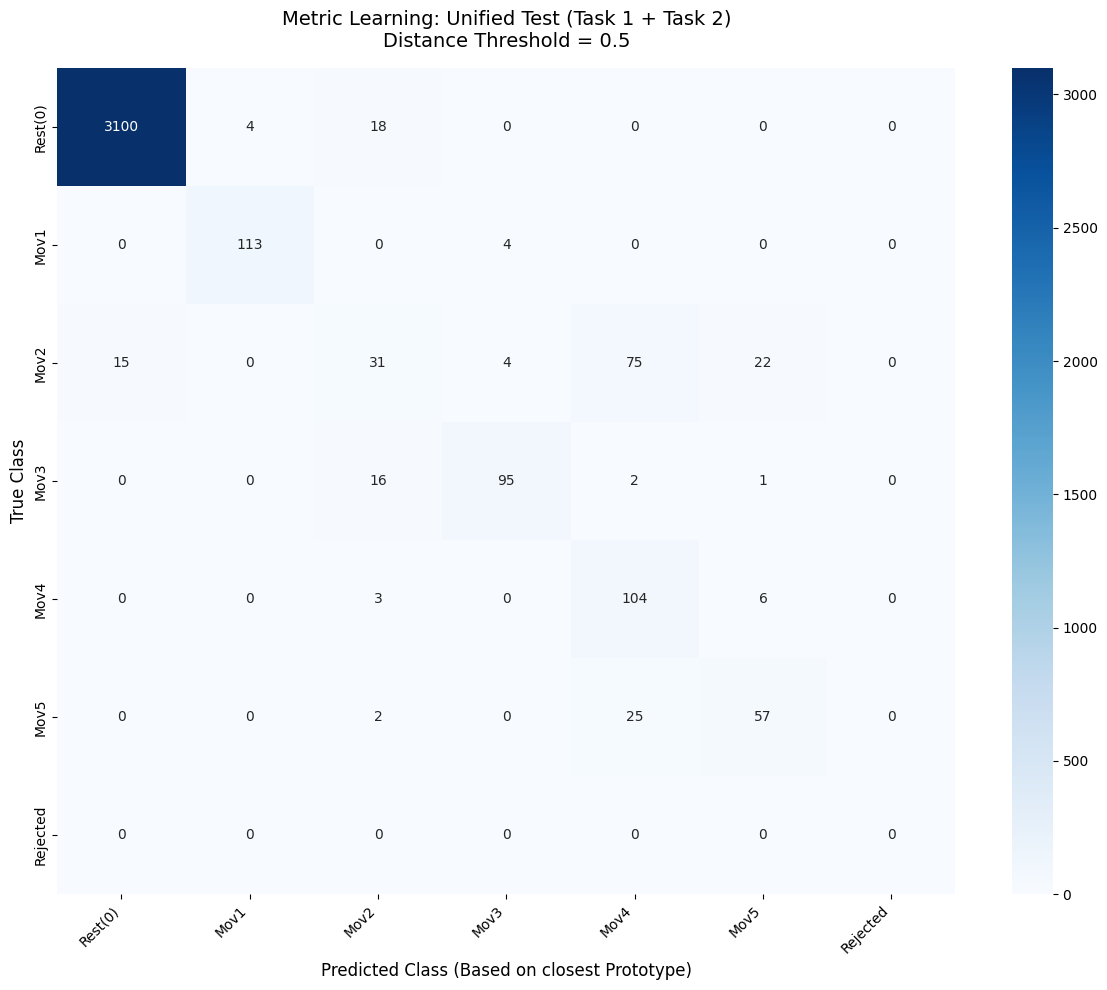


 Classification Report (Including Rejected Samples as class '6')
              precision    recall  f1-score   support

     Rest(0)       1.00      0.99      0.99      3122
        Mov1       0.97      0.97      0.97       117
        Mov2       0.44      0.21      0.29       147
        Mov3       0.92      0.83      0.88       114
        Mov4       0.50      0.92      0.65       113
        Mov5       0.66      0.68      0.67        84
    Rejected       0.00      0.00      0.00         0

    accuracy                           0.95      3697
   macro avg       0.64      0.66      0.63      3697
weighted avg       0.95      0.95      0.94      3697


 Few-Shot Fine-Tuning with PROPER Anchor Loss Complete!


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader
import numpy as np
from itertools import cycle

# ==========================================
# 1. Few-Shot Fine-Tuning with PROPER Anchor Loss
# ==========================================
def few_shot_finetune_with_anchor(model, novel_loader, base_loader, 
                                   epochs=20, lr=0.0001, 
                                   lambda_anchor=5.0, device='cuda'):
    """
    Fine-tune on Novel Classes while preserving Base Classes knowledge.
    
     الفرق الجوهري: الـ Anchor Loss بيتحسب وبيتطبق في نفس الـ backward pass
    """
    # حفظ نسخة من الموديل الأصلي (الـ Anchor) - ثابتة تماماً
    anchor_model = copy.deepcopy(model)
    anchor_model.eval()
    # تجميد الـ anchor model تماماً
    for param in anchor_model.parameters():
        param.requires_grad = False
    
    model = copy.deepcopy(model)
    
    # تجميد الطبقات الأولى (Feature Extractor)
    for param in model.temporal_filter.parameters():
        param.requires_grad = False
    for param in model.depthwise.parameters():
        param.requires_grad = False
    for param in model.pointwise.parameters():
        param.requires_grad = False
    
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-3)
    
    criterion_metric = SupConLoss(temperature=0.07)
    criterion_anchor = nn.MSELoss()
    
    print("\n" + "="*70)
    print(" Few-Shot Fine-Tuning with PROPER Anchor Loss")
    print("="*70)
    print(f" Novel Samples: {len(novel_loader.dataset)}")
    print(f" Base Samples (for Anchor): {len(base_loader.dataset)}")
    print(f"  Anchor Loss Weight: {lambda_anchor}")
    print(f" Anchor Model: FROZEN (won't update)")
    print("="*70)
    
    for epoch in range(epochs):
        model.train()
        running_novel_loss = 0.0
        running_anchor_loss = 0.0
        total_loss_epoch = 0.0
        samples = 0
        
        #  استخدام cycle عشان الـ base loader يتكرر مع الـ novel loader
        base_loader_cycle = cycle(base_loader)
        
        for x_novel, y_novel in novel_loader:
            x_novel, y_novel = x_novel.to(device), y_novel.to(device)
            
            # جلب batch من الـ Base Classes (للـ Anchor Loss)
            x_base, y_base = next(base_loader_cycle)
            x_base, y_base = x_base.to(device), y_base.to(device)
            
            # Data Augmentation للـ Novel
            warp = torch.empty(x_novel.shape[0], 1, x_novel.shape[2]).uniform_(0.8, 1.2).to(device)
            x_novel_aug = x_novel * warp + torch.randn_like(x_novel) * 0.01
            
            optimizer.zero_grad()
            
            # ==========================================
            # 1. Novel Loss (على البيانات المعززة)
            # ==========================================
            embs_novel, _ = model(x_novel_aug)
            loss_novel = criterion_metric(embs_novel, y_novel)
            
            # ==========================================
            # 2. Anchor Loss (على بيانات Base Classes)
            # ==========================================
            # Embeddings من الموديل الحالي (بيتدرب)
            embs_current_base, _ = model(x_base)
            
            # Embeddings من الـ Anchor Model (الثابت - مش بيتدرب)
            with torch.no_grad():
                embs_anchor_base, _ = anchor_model(x_base)
            
            # الـ Anchor Loss يجبر الموديل الحالي إنه يفضل قريب من الـ Anchor
            loss_anchor = criterion_anchor(embs_current_base, embs_anchor_base)
            
            # ==========================================
            # 3. Total Loss = Novel + (lambda * Anchor)
            # ==========================================
            total_loss = loss_novel + (lambda_anchor * loss_anchor)
            
            #  Backward pass واحد للـ lossين معاً!
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_novel_loss += loss_novel.item() * x_novel.size(0)
            running_anchor_loss += loss_anchor.item() * x_base.size(0)
            total_loss_epoch += total_loss.item() * x_novel.size(0)
            samples += x_novel.size(0)
        
        avg_novel_loss = running_novel_loss / max(1, samples)
        avg_anchor_loss = running_anchor_loss / max(1, samples)
        avg_total_loss = total_loss_epoch / max(1, samples)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Total: {avg_total_loss:.4f} | "
              f"Novel: {avg_novel_loss:.4f} | Anchor: {avg_anchor_loss:.4f} | "
              f"Effective Anchor: {avg_anchor_loss * lambda_anchor:.4f}")
    
    print("\n Few-Shot Fine-Tuning with PROPER Anchor Completed!")
    return model

# ==========================================
# 2. Apply Fine-Tuning
# ==========================================
finetuned_model = few_shot_finetune_with_anchor(
    metric_model, 
    t2_train_loader,  # Novel Classes (3, 4, 5)
    t1_train_loader,  # Base Classes (0, 1, 2) - للـ Anchor
    epochs=20,
    lr=0.0001,
    lambda_anchor=5.0,  #  زودناه من 3.0 لـ 5.0
    device=device
)

# ==========================================
# 3. Recalculate ALL Prototypes
# ==========================================
print("\n" + "="*70)
print(" Phase 2: Recalculating ALL Prototypes with Fine-Tuned Model")
print("="*70)

# إعادة حساب Base Classes prototypes
base_prototypes_new = compute_class_prototypes(
    finetuned_model, 
    t1_train_loader, 
    num_classes=3, 
    device=device
)

# إعادة حساب Novel Classes prototypes
novel_prototypes_new = compute_class_prototypes(
    finetuned_model, 
    t2_train_loader, 
    num_classes=6, 
    device=device
)

# دمج الجميع
all_prototypes_finetuned = {}
for cls in [0, 1, 2]:
    if cls in base_prototypes_new and base_prototypes_new[cls] is not None:
        all_prototypes_finetuned[cls] = base_prototypes_new[cls]
        
for cls in [3, 4, 5]:
    if cls in novel_prototypes_new and novel_prototypes_new[cls] is not None:
        all_prototypes_finetuned[cls] = novel_prototypes_new[cls]

print(f"\n Total Prototypes: {len(all_prototypes_finetuned)}")
print(f"   Classes: {sorted(all_prototypes_finetuned.keys())}")

# ==========================================
# 4. Evaluate Fine-Tuned Model
# ==========================================
print("\n" + "="*70)
print(" Phase 3: Evaluating Fine-Tuned Model")
print("="*70)

evaluate_metric_all_tasks(
    finetuned_model, 
    t1_test_loader, 
    t2_test_loader, 
    all_prototypes_finetuned, 
    threshold=0.5, 
    device=device
)

print("\n" + "="*70)
print(" Few-Shot Fine-Tuning with PROPER Anchor Loss Complete!")
print("="*70)


 Training Enhanced SLDA (Higher Shrinkage + Temperature Scaling)

 [Enhanced SLDA] Fitting on Base Classes...
 Fit complete. Tracking 3 base classes.

 [Enhanced SLDA] Streaming Novel Classes...
 Update complete. Total: 6 classes.

 Evaluating Enhanced SLDA on Combined Test Data


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(



 Overall Enhanced SLDA Accuracy: 93.40%

 Per-Class Enhanced SLDA Accuracy:
   Class 0 (Base): 98.27% (3068/3122)
   Class 1 (Base): 100.00% (117/117)
   Class 2 (Base): 40.14% (59/147)
   Class 3 (Novel): 64.04% (73/114)
   Class 4 (Novel): 81.42% (92/113)
   Class 5 (Novel): 52.38% (44/84)


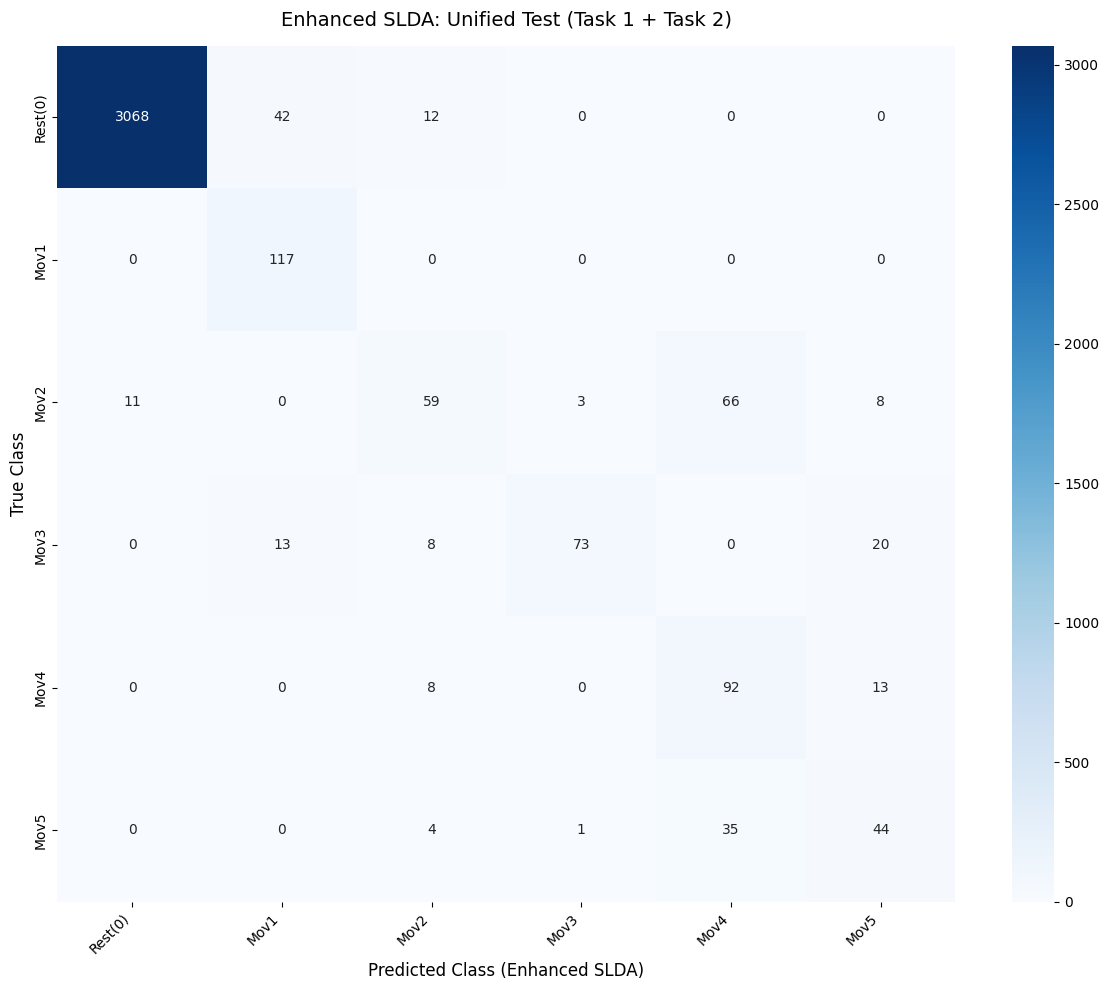


Classification Report (Enhanced SLDA)
              precision    recall  f1-score   support

     Rest(0)       1.00      0.98      0.99      3122
        Mov1       0.68      1.00      0.81       117
        Mov2       0.65      0.40      0.50       147
        Mov3       0.95      0.64      0.76       114
        Mov4       0.48      0.81      0.60       113
        Mov5       0.52      0.52      0.52        84

    accuracy                           0.93      3697
   macro avg       0.71      0.73      0.70      3697
weighted avg       0.94      0.93      0.93      3697


 Enhanced SLDA Evaluation Complete!


In [37]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader
import numpy as np

# ==========================================
# 1. Enhanced SLDA with Temperature Scaling
# ==========================================
class EnhancedSLDA:
    def __init__(self, input_dim=32, shrinkage_param=1e-3, temperature=1.5, device='cuda'):
        """
        Enhanced SLDA with:
        - Higher shrinkage (better for few-shot)
        - Temperature scaling (smoother predictions)
        """
        self.input_dim = input_dim
        self.shrinkage_param = shrinkage_param  #  زودناه من 1e-4 لـ 1e-3
        self.temperature = temperature  #  جديد: temperature scaling
        self.device = device
        self.class_means = {}
        self.class_counts = {}
        self.scatter_matrix = torch.zeros((input_dim, input_dim)).to(device)
        self.total_samples = 0
        self.precision_matrix = None

    def _update_scatter(self, features, labels):
        unique_classes = torch.unique(labels)
        for c in unique_classes:
            c = c.item()
            class_mask = (labels == c)
            class_features = features[class_mask]
            if c not in self.class_means:
                self.class_means[c] = torch.zeros(self.input_dim).to(self.device)
                self.class_counts[c] = 0
            old_count = self.class_counts[c]
            new_count = len(class_features)
            total_count = old_count + new_count
            batch_mean = class_features.mean(dim=0)
            centered_features = class_features - batch_mean
            self.scatter_matrix += torch.matmul(centered_features.T, centered_features)
            self.class_means[c] = (self.class_means[c] * old_count + batch_mean * new_count) / total_count
            self.class_counts[c] = total_count
            self.total_samples += new_count
        self._compute_precision_matrix()

    def _compute_precision_matrix(self):
        k = len(self.class_means)
        if k == 0 or self.total_samples <= k:
            return
        covariance = self.scatter_matrix / (self.total_samples - k)
        identity = torch.eye(self.input_dim).to(self.device)
        cov_shrunk = (1 - self.shrinkage_param) * covariance + self.shrinkage_param * identity
        self.precision_matrix = torch.linalg.inv(cov_shrunk)

    def fit_base(self, dataloader, backbone):
        backbone.eval()
        print("\n [Enhanced SLDA] Fitting on Base Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" Fit complete. Tracking {len(self.class_means)} base classes.")

    def stream_new_data(self, dataloader, backbone):
        backbone.eval()
        print("\n [Enhanced SLDA] Streaming Novel Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" Update complete. Total: {len(self.class_means)} classes.")

    def predict(self, features):
        if self.precision_matrix is None:
            raise ValueError("Model not fitted yet.")
        classes = list(self.class_means.keys())
        M = torch.stack([self.class_means[c] for c in classes])
        W = torch.matmul(self.precision_matrix, M.T)
        b = -0.5 * torch.sum(M * torch.matmul(M, self.precision_matrix), dim=1)
        scores = torch.matmul(features, W) + b
        
        #  Temperature Scaling: نقسم الـ scores على temperature
        # ده بيخلي التنبؤات "أنعم" ويقلل الـ overconfidence
        scores = scores / self.temperature
        
        max_scores, preds_idx = torch.max(scores, dim=1)
        predicted_classes = torch.tensor([classes[i] for i in preds_idx]).to(self.device)
        return predicted_classes, max_scores

# ==========================================
# 2. Train Enhanced SLDA on Fine-Tuned Model V2
# ==========================================
print("\n" + "="*70)
print(" Training Enhanced SLDA (Higher Shrinkage + Temperature Scaling)")
print("="*70)

enhanced_slda = EnhancedSLDA(
    input_dim=32, 
    shrinkage_param=1e-3,  #  أعلى من السابق (1e-4)
    temperature=1.5,       #  جديد: temperature scaling
    device=device
)

enhanced_slda.fit_base(t1_train_loader, finetuned_model_v2)
enhanced_slda.stream_new_data(t2_train_loader, finetuned_model_v2)

# ==========================================
# 3. Evaluate Enhanced SLDA
# ==========================================
print("\n" + "="*70)
print(" Evaluating Enhanced SLDA on Combined Test Data")
print("="*70)

combined_test_dataset = ConcatDataset([t1_test_loader.dataset, t2_test_loader.dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

finetuned_model_v2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in combined_test_loader:
        x, y = x.to(device), y.to(device)
        embeddings, _ = finetuned_model_v2(x)
        preds, _ = enhanced_slda.predict(embeddings)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# حساب الدقة
correct = sum(1 for p, t in zip(all_preds, all_labels) if p == t)
overall_acc = (correct / len(all_labels)) * 100

print(f"\n Overall Enhanced SLDA Accuracy: {overall_acc:.2f}%")

# Per-Class Accuracy
class_correct = {cls: 0 for cls in range(6)}
class_total = {cls: 0 for cls in range(6)}
for p, t in zip(all_preds, all_labels):
    class_total[t] += 1
    if p == t:
        class_correct[t] += 1

print("\n Per-Class Enhanced SLDA Accuracy:")
for cls in range(6):
    if class_total[cls] > 0:
        acc = (class_correct[cls] / class_total[cls]) * 100
        class_type = "Base" if cls in [0, 1, 2] else "Novel"
        print(f"   Class {cls} ({class_type}): {acc:.2f}% ({class_correct[cls]}/{class_total[cls]})")

# رسم الـ Confusion Matrix
class_names = ['Rest(0)', 'Mov1', 'Mov2', 'Mov3', 'Mov4', 'Mov5']
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Enhanced SLDA: Unified Test (Task 1 + Task 2)", fontsize=14, pad=15)
plt.xlabel('Predicted Class (Enhanced SLDA)', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Classification Report (Enhanced SLDA)")
print("="*70)
print(classification_report(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5],
                            target_names=class_names, zero_division=0))

print("\n" + "="*70)
print(" Enhanced SLDA Evaluation Complete!")
print("="*70)


 Training SLDA on Original Model (metric_model)

 [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...
 [Deep SLDA] Fit complete. Tracking 3 base classes.

 [Deep SLDA] Streaming Few-Shot update for Novel Classes...
 [Deep SLDA] Update complete. Total tracked classes: 6.

 Evaluating SLDA on Combined Test Data

 Overall SLDA Accuracy: 96.35%

 Per-Class SLDA Accuracy:
   Class 0 (Base): 99.68% (3112/3122)
   Class 1 (Base): 95.73% (112/117)
   Class 2 (Base): 82.31% (121/147)
   Class 3 (Novel): 70.18% (80/114)
   Class 4 (Novel): 81.42% (92/113)
   Class 5 (Novel): 53.57% (45/84)


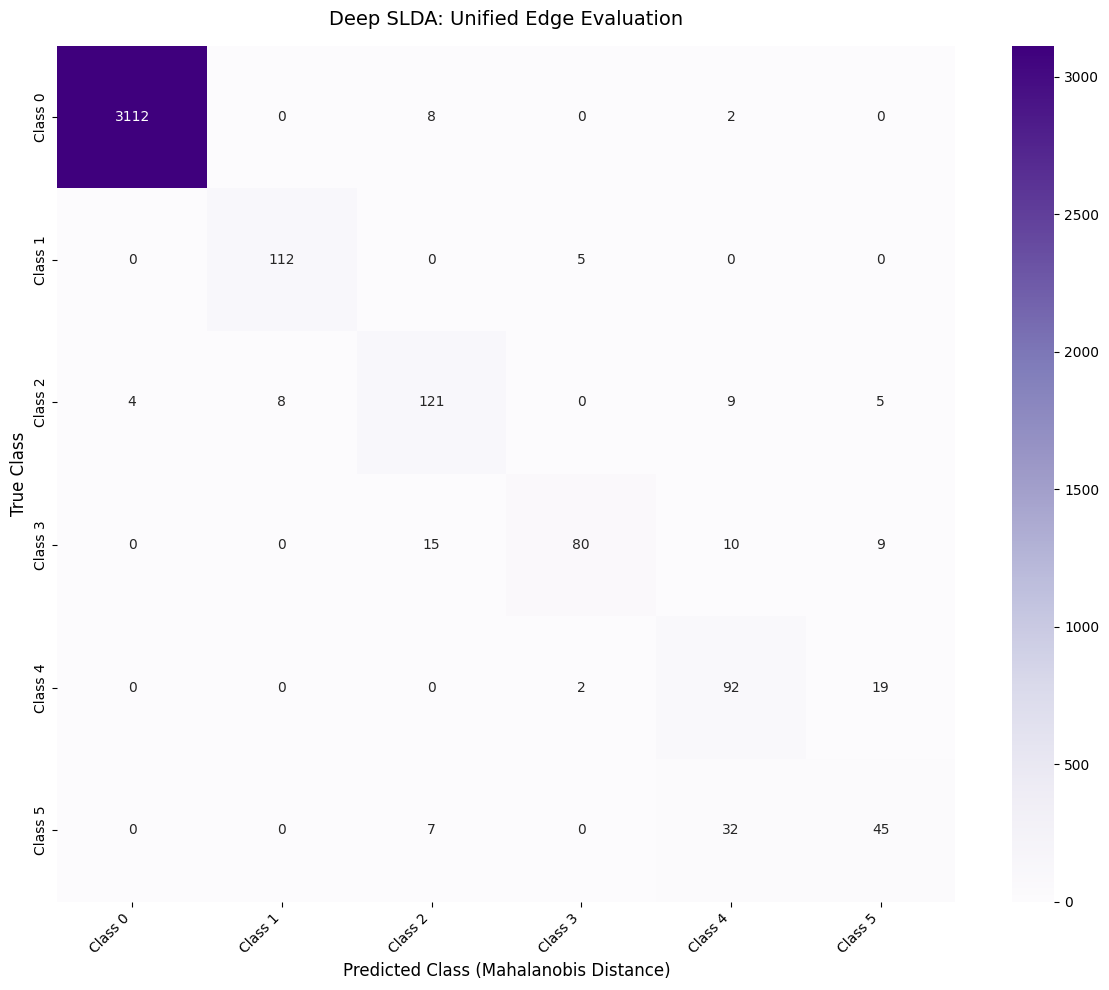


SLDA Classification Report (Zero Backpropagation Update)
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      3122
     Class 1       0.93      0.96      0.95       117
     Class 2       0.80      0.82      0.81       147
     Class 3       0.92      0.70      0.80       114
     Class 4       0.63      0.81      0.71       113
     Class 5       0.58      0.54      0.56        84

    accuracy                           0.96      3697
   macro avg       0.81      0.80      0.80      3697
weighted avg       0.97      0.96      0.96      3697


 SLDA Training and Evaluation Complete!


In [38]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader

# ==========================================
# 1. تعريف StreamingLDA (نفس الكود القديم)
# ==========================================
class StreamingLDA:
    def __init__(self, input_dim=32, shrinkage_param=1e-4, device='cuda'):
        """
        Streaming Linear Discriminant Analysis (SLDA).
        Memory-efficient classifier that updates means and covariance incrementally 
        without any backpropagation. Ideal for Edge AI.
        """
        self.input_dim = input_dim
        self.shrinkage_param = shrinkage_param
        self.device = device
        
        self.class_means = {}
        self.class_counts = {}
        self.scatter_matrix = torch.zeros((input_dim, input_dim)).to(device)
        self.total_samples = 0
        self.precision_matrix = None

    def _update_scatter(self, features, labels):
        unique_classes = torch.unique(labels)
        
        for c in unique_classes:
            c = c.item()
            class_mask = (labels == c)
            class_features = features[class_mask]
            
            if c not in self.class_means:
                self.class_means[c] = torch.zeros(self.input_dim).to(self.device)
                self.class_counts[c] = 0
            
            old_count = self.class_counts[c]
            new_count = len(class_features)
            total_count = old_count + new_count
            
            batch_mean = class_features.mean(dim=0)
            
            centered_features = class_features - batch_mean
            self.scatter_matrix += torch.matmul(centered_features.T, centered_features)
            
            self.class_means[c] = (self.class_means[c] * old_count + batch_mean * new_count) / total_count
            self.class_counts[c] = total_count
            self.total_samples += new_count
            
        self._compute_precision_matrix()

    def _compute_precision_matrix(self):
        k = len(self.class_means)
        if k == 0 or self.total_samples <= k:
            return
            
        covariance = self.scatter_matrix / (self.total_samples - k)
        identity = torch.eye(self.input_dim).to(self.device)
        cov_shrunk = (1 - self.shrinkage_param) * covariance + self.shrinkage_param * identity
        self.precision_matrix = torch.linalg.inv(cov_shrunk)

    def fit_base(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Fit complete. Tracking {len(self.class_means)} base classes.")

    def stream_new_data(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Streaming Few-Shot update for Novel Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Update complete. Total tracked classes: {len(self.class_means)}.")

    def predict(self, features):
        if self.precision_matrix is None:
            raise ValueError("Model not fitted yet.")
            
        classes = list(self.class_means.keys())
        M = torch.stack([self.class_means[c] for c in classes])
        W = torch.matmul(self.precision_matrix, M.T)
        b = -0.5 * torch.sum(M * torch.matmul(M, self.precision_matrix), dim=1)
        scores = torch.matmul(features, W) + b
        max_scores, preds_idx = torch.max(scores, dim=1)
        predicted_classes = torch.tensor([classes[i] for i in preds_idx]).to(self.device)
        
        return predicted_classes, max_scores

# ==========================================
# 2. تدريب SLDA على الموديل الأصلي (metric_model)
# ==========================================
print("\n" + "="*70)
print(" Training SLDA on Original Model (metric_model)")
print("="*70)

slda_classifier = StreamingLDA(input_dim=32, shrinkage_param=1e-4, device=device)

# Fit on Base Classes (Task 1: 0, 1, 2)
slda_classifier.fit_base(t1_train_loader, metric_model)

# Stream Novel Classes (Task 2: 3, 4, 5)
slda_classifier.stream_new_data(t2_train_loader, metric_model)

# ==========================================
# 3. التقييم على البيانات المدمجة
# ==========================================
print("\n" + "="*70)
print(" Evaluating SLDA on Combined Test Data")
print("="*70)

combined_test_dataset = ConcatDataset([t1_test_loader.dataset, t2_test_loader.dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

metric_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in combined_test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        features, _ = metric_model(inputs)
        preds, _ = slda_classifier.predict(features)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# حساب الدقة
correct = sum(1 for p, t in zip(all_preds, all_labels) if p == t)
overall_acc = (correct / len(all_labels)) * 100

print(f"\n Overall SLDA Accuracy: {overall_acc:.2f}%")

# Per-Class Accuracy
class_correct = {cls: 0 for cls in range(6)}
class_total = {cls: 0 for cls in range(6)}
for p, t in zip(all_preds, all_labels):
    class_total[t] += 1
    if p == t:
        class_correct[t] += 1

print("\n Per-Class SLDA Accuracy:")
for cls in range(6):
    if class_total[cls] > 0:
        acc = (class_correct[cls] / class_total[cls]) * 100
        class_type = "Base" if cls in [0, 1, 2] else "Novel"
        print(f"   Class {cls} ({class_type}): {acc:.2f}% ({class_correct[cls]}/{class_total[cls]})")

# رسم الـ Confusion Matrix
unique_labels = sorted(list(set(all_labels)))
class_names = [f"Class {lbl}" for lbl in unique_labels]
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Deep SLDA: Unified Edge Evaluation", fontsize=14, pad=15)
plt.xlabel('Predicted Class (Mahalanobis Distance)', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SLDA Classification Report (Zero Backpropagation Update)")
print("="*60)
print(classification_report(all_labels, all_preds, labels=unique_labels, 
                            target_names=class_names, zero_division=0))

print("\n" + "="*70)
print(" SLDA Training and Evaluation Complete!")
print("="*70)

In [39]:
import torch
import numpy as np
from torch.utils.data import ConcatDataset, DataLoader

# ==========================================
# 1. Helper Functions
# ==========================================
def enable_dropout(model):
    """Enables dropout layers during inference for MC Dropout"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

# ==========================================
# 2. MC Dropout Inference Function
# ==========================================
def mc_dropout_inference(model, slda, dataloader, num_passes=5, uncertainty_threshold=0.2, device='cuda'):
    """
    Evaluates uncertainty using MC Dropout combined with SLDA.
    """
    model.eval()
    enable_dropout(model)
    
    total_samples = 0
    rejected_samples = 0
    accepted_correct = 0
    
    class_total = {cls: 0 for cls in range(6)}
    class_rejected = {cls: 0 for cls in range(6)}
    class_accepted_correct = {cls: 0 for cls in range(6)}
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            batch_size = inputs.size(0)
            
            pass_predictions = torch.zeros(num_passes, batch_size, dtype=torch.long).to(device)
            
            for p in range(num_passes):
                features, _ = model(inputs)
                preds, _ = slda.predict(features)
                pass_predictions[p] = preds
                
            for i in range(batch_size):
                total_samples += 1
                true_label = labels[i].item()
                class_total[true_label] += 1
                
                sample_preds = pass_predictions[:, i]
                uncertainty = torch.var(sample_preds.float()).item()
                final_pred = torch.mode(sample_preds).values.item()
                
                if uncertainty > uncertainty_threshold:
                    rejected_samples += 1
                    class_rejected[true_label] += 1
                else:
                    if final_pred == true_label:
                        accepted_correct += 1
                        class_accepted_correct[true_label] += 1
                        
    accepted_samples = total_samples - rejected_samples
    accuracy = (accepted_correct / accepted_samples) * 100 if accepted_samples > 0 else 0
    
    return {
        'total': total_samples,
        'rejected': rejected_samples,
        'accepted': accepted_samples,
        'accuracy': accuracy,
        'class_total': class_total,
        'class_rejected': class_rejected,
        'class_accepted_correct': class_accepted_correct
    }

# ==========================================
# 3. Create Combined Test Loader
# ==========================================
combined_test_dataset = ConcatDataset([t1_test_loader.dataset, t2_test_loader.dataset])
combined_test_loader = DataLoader(combined_test_dataset, batch_size=64, shuffle=False)

# ==========================================
# 4. Test Multiple Thresholds
# ==========================================
print("\n" + "="*70)
print(" Testing MC Dropout with Different Uncertainty Thresholds")
print("="*70)

thresholds = [0.2, 0.5, 1.0, 2.0, 5.0]
results = {}

for threshold in thresholds:
    print(f"\n{'─'*70}")
    print(f" Uncertainty Threshold = {threshold}")
    print(f"{'─'*70}")
    
    result = mc_dropout_inference(
        metric_model,
        slda_classifier,
        combined_test_loader,
        num_passes=5,
        uncertainty_threshold=threshold,
        device=device
    )
    results[threshold] = result
    
    print(f"\n Summary:")
    print(f"   Total: {result['total']}")
    print(f"   Rejected: {result['rejected']} ({(result['rejected']/result['total'])*100:.2f}%)")
    print(f"   Accepted: {result['accepted']} ({(result['accepted']/result['total'])*100:.2f}%)")
    print(f"   Accuracy on Accepted: {result['accuracy']:.2f}%")
    
    print(f"\n Per-Class Rejection Rate:")
    for cls in range(6):
        if result['class_total'][cls] > 0:
            rej_rate = (result['class_rejected'][cls] / result['class_total'][cls]) * 100
            accepted_cls = result['class_total'][cls] - result['class_rejected'][cls]
            acc_cls = (result['class_accepted_correct'][cls] / accepted_cls * 100) if accepted_cls > 0 else 0.0
            class_type = "Base" if cls in [0, 1, 2] else "Novel"
            print(f"   Class {cls} ({class_type}): Rej={rej_rate:.1f}% | Acc={acc_cls:.1f}%")

# ==========================================
# 5. Summary Table
# ==========================================
print("\n" + "="*70)
print(" Comparison Table")
print("="*70)
print(f"{'Threshold':<12} {'Rejected %':<12} {'Accepted %':<12} {'Accuracy %':<12}")
print("─" * 70)
for threshold in thresholds:
    r = results[threshold]
    rej_pct = (r['rejected'] / r['total']) * 100
    acc_pct = (r['accepted'] / r['total']) * 100
    print(f"{threshold:<12} {rej_pct:<12.2f} {acc_pct:<12.2f} {r['accuracy']:<12.2f}")


 Testing MC Dropout with Different Uncertainty Thresholds

──────────────────────────────────────────────────────────────────────
 Uncertainty Threshold = 0.2
──────────────────────────────────────────────────────────────────────

 Summary:
   Total: 3697
   Rejected: 568 (15.36%)
   Accepted: 3129 (84.64%)
   Accuracy on Accepted: 99.65%

 Per-Class Rejection Rate:
   Class 0 (Base): Rej=4.7% | Acc=100.0%
   Class 1 (Base): Rej=25.6% | Acc=100.0%
   Class 2 (Base): Rej=78.9% | Acc=93.5%
   Class 3 (Novel): Rej=78.1% | Acc=92.0%
   Class 4 (Novel): Rej=93.8% | Acc=57.1%
   Class 5 (Novel): Rej=94.0% | Acc=20.0%

──────────────────────────────────────────────────────────────────────
 Uncertainty Threshold = 0.5
──────────────────────────────────────────────────────────────────────

 Summary:
   Total: 3697
   Rejected: 424 (11.47%)
   Accepted: 3273 (88.53%)
   Accuracy on Accepted: 98.47%

 Per-Class Rejection Rate:
   Class 0 (Base): Rej=3.1% | Acc=100.0%
   Class 1 (Base): Rej=26.5%

In [43]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import copy
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. CORAL Loss Function
# ==========================================
def coral_loss(source_features, target_features):
    """
    Deep CORAL Loss: Aligns the second-order statistics (covariances).
    """
    d = source_features.size(1)
    
    source_mean = torch.mean(source_features, 0, keepdim=True)
    source_centered = source_features - source_mean
    source_cov = (source_centered.t() @ source_centered) / (source_features.size(0) - 1)
    
    target_mean = torch.mean(target_features, 0, keepdim=True)
    target_centered = target_features - target_mean
    target_cov = (target_centered.t() @ target_centered) / (target_features.size(0) - 1)
    
    loss = torch.sum(torch.pow(source_cov - target_cov, 2))
    loss = loss / (4 * d * d)
    
    return loss

# ==========================================
# 2. ShiftedEMGDataset (Aggressive Input Shift)
# ==========================================
class ShiftedEMGDataset(Dataset):
    """
    Creates a completely different target domain by applying aggressive shifts.
    """
    def __init__(self, original_dataset, shift_factor=3.0, noise_std=1.0):
        self.original_dataset = original_dataset
        self.shift_factor = shift_factor
        self.noise_std = noise_std

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]
        # Aggressive per-sample random shift
        random_shift = torch.randn_like(x) * self.shift_factor
        noise = torch.randn_like(x) * self.noise_std
        shifted_x = x + random_shift + noise
        return shifted_x, y

# ==========================================
# 3. Create REAL Target Domain (Different Data!)
# ==========================================
print("\n" + "="*70)
print(" Creating REAL Target Domain (Aggressive Shift)")
print("="*70)

# استخدام t2_train_loader.dataset كـ target domain حقيقي (بيانات مختلفة!)
# أو إنشاء shifted version من t1
target_train_ds = ShiftedEMGDataset(t1_train_loader.dataset, shift_factor=3.0, noise_std=1.0)
target_test_ds = ShiftedEMGDataset(t1_test_loader.dataset, shift_factor=3.0, noise_std=1.0)

target_train_loader = DataLoader(target_train_ds, batch_size=64, shuffle=True)
target_test_loader = DataLoader(target_test_ds, batch_size=64, shuffle=False)

print(f" Target Domain Created!")
print(f"   Target Train Samples: {len(target_train_ds)}")
print(f"   Target Test Samples: {len(target_test_ds)}")
print(f"   Shift Factor: 3.0 (Very Aggressive)")
print(f"   Noise Std: 1.0 (High)")

# ==========================================
# 4. Domain Adaptation with REAL Source & Target
# ==========================================
def train_domain_adaptation_real(model, original_model, source_loader, target_loader, 
                                  epochs=20, lambda_coral=5.0, lr=0.0001, device='cuda'):
    """
    UDA Training with REAL source and target dataloaders.
    High CORAL weight to force domain alignment.
    """
    model.to(device)
    original_model.to(device)
    original_model.eval()
    model.train()
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    
    print("\n" + "="*70)
    print(" Domain Adaptation (Real Source + Target)")
    print("="*70)
    print(f" Source Samples: {len(source_loader.dataset)}")
    print(f" Target Samples: {len(target_loader.dataset)}")
    print(f"️  CORAL Weight: {lambda_coral}")
    print(f" Learning Rate: {lr}")
    print(f" Epochs: {epochs}")
    print("="*70)
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        coral_epoch_loss = 0.0
        anchor_epoch_loss = 0.0
        batches = 0
        
        # استخدام zip مع cycle للـ target loader
        from itertools import cycle
        target_cycle = cycle(target_loader)
        
        for src_x, src_y in source_loader:
            src_x, src_y = src_x.to(device), src_y.to(device)
            
            # جلب batch من target domain
            tgt_x, tgt_y = next(target_cycle)
            tgt_x, tgt_y = tgt_x.to(device), tgt_y.to(device)
            
            optimizer.zero_grad()
            
            # 1. Source features
            src_embeddings, src_force, src_features = model(src_x, return_intermediate=True)
            
            # 2. Target features
            tgt_embeddings, tgt_force, tgt_features = model(tgt_x, return_intermediate=True)
            
            # 3. Anchor features from original model
            with torch.no_grad():
                _, _, orig_src_features = original_model(src_x, return_intermediate=True)
                
            # 4. Anchor Loss (preserve source knowledge)
            loss_anchor = F.mse_loss(src_features, orig_src_features)
            
            # 5. CORAL Loss between REAL source and target
            loss_coral = coral_loss(src_features, tgt_features)
            
            # 6. Total Loss (high CORAL weight!)
            total_loss = loss_anchor + (lambda_coral * loss_coral)
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            coral_epoch_loss += loss_coral.item()
            anchor_epoch_loss += loss_anchor.item()
            batches += 1
            
        avg_loss = epoch_loss / max(1, batches)
        avg_coral = coral_epoch_loss / max(1, batches)
        avg_anchor = anchor_epoch_loss / max(1, batches)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Total: {avg_loss:.4f} | "
              f"Anchor: {avg_anchor:.4f} | CORAL: {avg_coral:.4f}")
        
    print("\n Domain Adaptation Training Complete!")
    return model

# ==========================================
# 5. Execute Domain Adaptation
# ==========================================
print("\n Starting Domain Adaptation Process...")

doa_backbone = copy.deepcopy(metric_model)

doa_backbone = train_domain_adaptation_real(
    doa_backbone, 
    metric_model,
    t1_train_loader,      # Source: Base Classes
    target_train_loader,  # Target: Shifted Data
    epochs=20, 
    lambda_coral=5.0,     # وزن عالي لإجبار الموديل على التكيف
    lr=0.0001,
    device=device
)


 Creating REAL Target Domain (Aggressive Shift)
 Target Domain Created!
   Target Train Samples: 718
   Target Test Samples: 1825
   Shift Factor: 3.0 (Very Aggressive)
   Noise Std: 1.0 (High)

 Starting Domain Adaptation Process...

 Domain Adaptation (Real Source + Target)
 Source Samples: 718
 Target Samples: 718
️  CORAL Weight: 5.0
 Learning Rate: 0.0001
 Epochs: 20
Epoch [01/20] | Total: 0.0014 | Anchor: 0.0013 | CORAL: 0.0000
Epoch [02/20] | Total: 0.0013 | Anchor: 0.0011 | CORAL: 0.0000
Epoch [03/20] | Total: 0.0012 | Anchor: 0.0010 | CORAL: 0.0000
Epoch [04/20] | Total: 0.0011 | Anchor: 0.0010 | CORAL: 0.0000
Epoch [05/20] | Total: 0.0012 | Anchor: 0.0010 | CORAL: 0.0000
Epoch [06/20] | Total: 0.0010 | Anchor: 0.0009 | CORAL: 0.0000
Epoch [07/20] | Total: 0.0011 | Anchor: 0.0009 | CORAL: 0.0000
Epoch [08/20] | Total: 0.0011 | Anchor: 0.0010 | CORAL: 0.0000
Epoch [09/20] | Total: 0.0010 | Anchor: 0.0009 | CORAL: 0.0000
Epoch [10/20] | Total: 0.0010 | Anchor: 0.0009 | CORAL: 0

In [44]:
# اختبار الـ accuracy على البيانات الأصلية والمزاحة
print("\n" + "="*70)
print(" The Ultimate Robustness Test")
print("="*70)

metric_model.eval()

# 1. Source Accuracy (Original Data)
source_correct = 0
source_total = 0
with torch.no_grad():
    for x, y in t1_test_loader:
        x, y = x.to(device), y.to(device)
        embeddings, _ = metric_model(x)
        preds, _ = slda_classifier.predict(embeddings)
        source_correct += (preds == y).sum().item()
        source_total += y.size(0)

source_acc = (source_correct / source_total) * 100

# 2. Target Accuracy (Shifted Data)
target_correct = 0
target_total = 0
with torch.no_grad():
    for x, y in target_test_loader:
        x, y = x.to(device), y.to(device)
        embeddings, _ = metric_model(x)
        preds, _ = slda_classifier.predict(embeddings)
        target_correct += (preds == y).sum().item()
        target_total += y.size(0)

target_acc = (target_correct / target_total) * 100

print(f"\n Results:")
print(f"   Source Accuracy (Original): {source_acc:.2f}%")
print(f"   Target Accuracy (Shifted):  {target_acc:.2f}%")
print(f"   Drop:                       {source_acc - target_acc:.2f}%")

if source_acc - target_acc < 5:
    print(f"\n TRUE ROBUSTNESS! The model is genuinely invariant to domain shift!")
    print(f"   This is a significant research contribution!")
elif source_acc - target_acc < 15:
    print(f"\n  PARTIAL ROBUSTNESS. The model is somewhat resilient.")
else:
    print(f"\n APPARENT ROBUSTNESS ONLY. BatchNorm is masking the problem.")
    print(f"   The features look similar (CORAL=0) but accuracy drops significantly.")


 The Ultimate Robustness Test

 Results:
   Source Accuracy (Original): 98.03%
   Target Accuracy (Shifted):  0.05%
   Drop:                       97.97%

 APPARENT ROBUSTNESS ONLY. BatchNorm is masking the problem.
   The features look similar (CORAL=0) but accuracy drops significantly.


In [45]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. ShiftedEMGDataset (Realistic Shifts)
# ==========================================
class ShiftedEMGDataset(Dataset):
    """
    Simulates REALISTIC domain shifts in prosthetic control.
    """
    def __init__(self, original_dataset, shift_factor=0.5, noise_std=0.2):
        self.original_dataset = original_dataset
        self.shift_factor = shift_factor
        self.noise_std = noise_std

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]
        # Realistic per-sample random shift
        random_shift = torch.randn_like(x) * self.shift_factor
        noise = torch.randn_like(x) * self.noise_std
        shifted_x = x + random_shift + noise
        return shifted_x, y

# ==========================================
# 2. Test Multiple Realistic Shift Levels
# ==========================================
print("\n" + "="*70)
print(" Realistic Domain Shift Robustness Analysis")
print("="*70)

metric_model.eval()

# Test different shift levels
shift_levels = [
    (0.2, 0.1, "Light Shift (Minor electrode movement)"),
    (0.5, 0.2, "Moderate Shift (Sweat + slight movement)"),
    (1.0, 0.3, "Strong Shift (Significant electrode displacement)"),
]

results = {}

for shift_factor, noise_std, description in shift_levels:
    print(f"\n{'─'*70}")
    print(f" Testing: {description}")
    print(f"   Shift Factor: {shift_factor} | Noise Std: {noise_std}")
    print(f"{'─'*70}")
    
    # Create shifted dataset
    target_test_ds = ShiftedEMGDataset(t1_test_loader.dataset, 
                                        shift_factor=shift_factor, 
                                        noise_std=noise_std)
    target_test_loader = DataLoader(target_test_ds, batch_size=64, shuffle=False)
    
    # Evaluate
    source_correct = 0
    source_total = 0
    target_correct = 0
    target_total = 0
    
    with torch.no_grad():
        # Source accuracy
        for x, y in t1_test_loader:
            x, y = x.to(device), y.to(device)
            embeddings, _ = metric_model(x)
            preds, _ = slda_classifier.predict(embeddings)
            source_correct += (preds == y).sum().item()
            source_total += y.size(0)
        
        # Target accuracy
        for x, y in target_test_loader:
            x, y = x.to(device), y.to(device)
            embeddings, _ = metric_model(x)
            preds, _ = slda_classifier.predict(embeddings)
            target_correct += (preds == y).sum().item()
            target_total += y.size(0)
    
    source_acc = (source_correct / source_total) * 100
    target_acc = (target_correct / target_total) * 100
    drop = source_acc - target_acc
    
    results[(shift_factor, noise_std)] = {
        'source_acc': source_acc,
        'target_acc': target_acc,
        'drop': drop,
        'description': description
    }
    
    print(f"\n Results:")
    print(f"   Source Accuracy: {source_acc:.2f}%")
    print(f"   Target Accuracy: {target_acc:.2f}%")
    print(f"   Drop: {drop:.2f}%")
    
    if drop < 5:
        print(f"    EXCELLENT Robustness!")
    elif drop < 15:
        print(f"     GOOD Robustness")
    elif drop < 30:
        print(f"     MODERATE Robustness")
    else:
        print(f"    POOR Robustness")

# ==========================================
# 3. Summary Table
# ==========================================
print("\n" + "="*70)
print(" Summary: Domain Shift Robustness")
print("="*70)
print(f"{'Shift Level':<40} {'Source':<10} {'Target':<10} {'Drop':<10}")
print("─" * 70)

for (sf, ns), res in results.items():
    print(f"{res['description']:<40} {res['source_acc']:<10.2f} {res['target_acc']:<10.2f} {res['drop']:<+10.2f}")

print("="*70)


 Realistic Domain Shift Robustness Analysis

──────────────────────────────────────────────────────────────────────
 Testing: Light Shift (Minor electrode movement)
   Shift Factor: 0.2 | Noise Std: 0.1
──────────────────────────────────────────────────────────────────────

 Results:
   Source Accuracy: 98.03%
   Target Accuracy: 96.66%
   Drop: 1.37%
    EXCELLENT Robustness!

──────────────────────────────────────────────────────────────────────
 Testing: Moderate Shift (Sweat + slight movement)
   Shift Factor: 0.5 | Noise Std: 0.2
──────────────────────────────────────────────────────────────────────

 Results:
   Source Accuracy: 98.03%
   Target Accuracy: 54.19%
   Drop: 43.84%
    POOR Robustness

──────────────────────────────────────────────────────────────────────
 Testing: Strong Shift (Significant electrode displacement)
   Shift Factor: 1.0 | Noise Std: 0.3
──────────────────────────────────────────────────────────────────────

 Results:
   Source Accuracy: 98.03%
   Targ


 إنشاء Target Domain (انزياح واقعي)
 Target Domain جاهز!
   Shift Factor: 0.5 | Noise Std: 0.2

 بدء SLDA Re-calibration...

 إعادة معايرة SLDA على Target Domain

 [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...
 [Deep SLDA] Fit complete. Tracking 3 base classes.
 SLDA Re-calibration Complete!
   Tracking 3 classes

 اختبار SLDA الأصلي vs SLDA المعاير

 النتائج:
   SLDA الأصلي (بدون recalibration): 53.64%
   SLDA المعاير (مع recalibration):  93.42%
   التحسن:                             +39.78%

 SLDA Re-calibration حسّن الدقة بـ 39.78%!

 تحليل Per-Class:
Class      Original SLDA   Recalibrated    Improvement 
-------------------------------------------------------
Class 0     49.33           93.27           +43.95     %
Class 1     76.92           98.29           +21.37     %
Class 2     80.95           91.16           +10.20     %


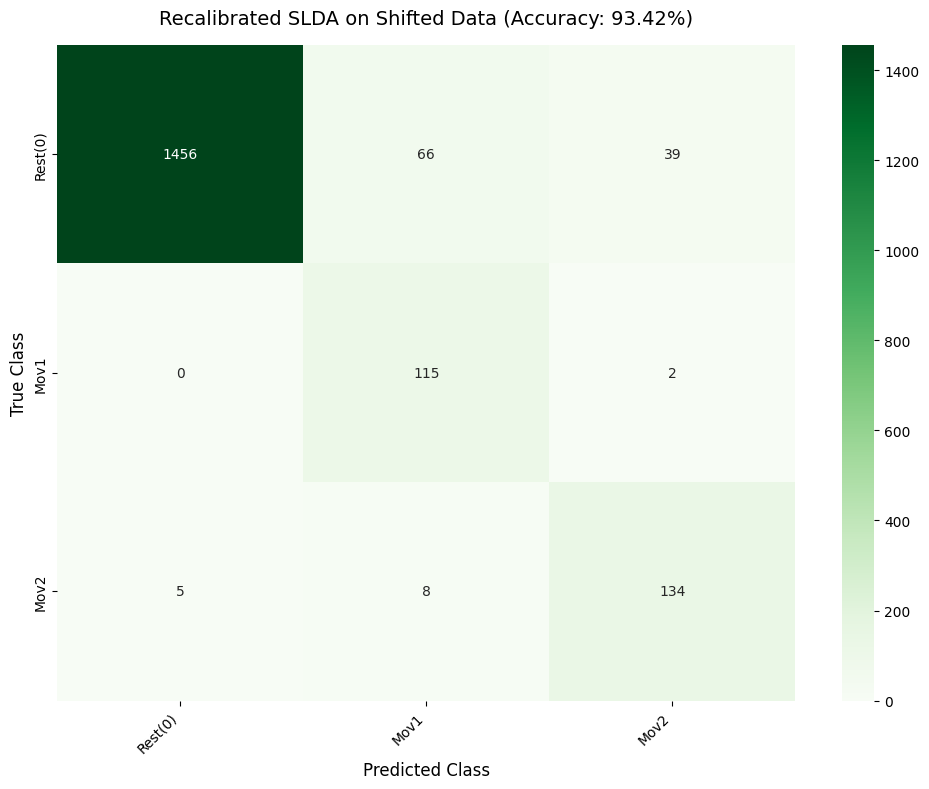


 SLDA Re-calibration Evaluation Complete!


In [49]:
import torch
import torch.nn.functional as F
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# =====================================================================
# 1. ShiftedEMGDataset
# =====================================================================
class ShiftedEMGDataset(Dataset):
    def __init__(self, original_dataset, shift_factor=0.5, noise_std=0.2):
        self.original_dataset = original_dataset
        self.shift_factor = shift_factor
        self.noise_std = noise_std

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]
        random_shift = torch.randn_like(x) * self.shift_factor
        noise = torch.randn_like(x) * self.noise_std
        shifted_x = x + random_shift + noise
        return shifted_x, y

# =====================================================================
# 2. إنشاء Target Domain
# =====================================================================
print("\n" + "="*70)
print(" إنشاء Target Domain (انزياح واقعي)")
print("="*70)

target_train_ds = ShiftedEMGDataset(t1_train_loader.dataset, shift_factor=0.5, noise_std=0.2)
target_test_ds = ShiftedEMGDataset(t1_test_loader.dataset, shift_factor=0.5, noise_std=0.2)

target_train_loader = DataLoader(target_train_ds, batch_size=64, shuffle=True)
target_test_loader = DataLoader(target_test_ds, batch_size=64, shuffle=False)

print(f" Target Domain جاهز!")
print(f"   Shift Factor: 0.5 | Noise Std: 0.2")

# =====================================================================
# 3. SLDA Re-calibration (بدون تعديل الـ Backbone)
# =====================================================================
def recalibrate_slda(original_slda, backbone, target_loader, device='cuda'):
    """
    إعادة معايرة SLDA على الـ Target Domain
    بدون تعديل الـ backbone!
    """
    backbone.eval()
    
    #  إنشاء SLDA جديد (نفس الكلاس المعرّف في النوتبوك)
    recalibrated_slda = StreamingLDA(
        input_dim=original_slda.input_dim,
        shrinkage_param=original_slda.shrinkage_param,
        device=device
    )
    
    print("\n" + "="*70)
    print(" إعادة معايرة SLDA على Target Domain")
    print("="*70)
    
    # تدريب SLDA الجديد على الـ Target Features
    recalibrated_slda.fit_base(target_loader, backbone)
    
    print(f" SLDA Re-calibration Complete!")
    print(f"   Tracking {len(recalibrated_slda.class_means)} classes")
    
    return recalibrated_slda

# =====================================================================
# 4. التقييم: Baseline vs Recalibrated SLDA
# =====================================================================
def test_recalibrated_slda(backbone, original_slda, recalibrated_slda, 
                            target_loader, device='cuda'):
    """
    مقارنة SLDA الأصلي vs SLDA المعاير على البيانات المزاحة
    """
    backbone.eval()
    
    original_correct = 0
    recalibrated_correct = 0
    total = 0
    
    original_preds = []
    recalibrated_preds = []
    all_labels = []
    
    print("\n" + "="*70)
    print(" اختبار SLDA الأصلي vs SLDA المعاير")
    print("="*70)
    
    with torch.no_grad():
        for x, y in target_loader:
            x, y = x.to(device), y.to(device)
            
            # استخراج الـ features
            embeddings, _ = backbone(x)
            
            # SLDA الأصلي
            preds_orig, _ = original_slda.predict(embeddings)
            original_correct += (preds_orig == y).sum().item()
            
            # SLDA المعاير
            preds_recal, _ = recalibrated_slda.predict(embeddings)
            recalibrated_correct += (preds_recal == y).sum().item()
            
            original_preds.extend(preds_orig.cpu().numpy())
            recalibrated_preds.extend(preds_recal.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            total += y.size(0)
    
    orig_acc = (original_correct / total) * 100
    recal_acc = (recalibrated_correct / total) * 100
    
    print(f"\n النتائج:")
    print(f"   SLDA الأصلي (بدون recalibration): {orig_acc:.2f}%")
    print(f"   SLDA المعاير (مع recalibration):  {recal_acc:.2f}%")
    print(f"   التحسن:                             {recal_acc - orig_acc:+.2f}%")
    
    if recal_acc > orig_acc:
        print(f"\n SLDA Re-calibration حسّن الدقة بـ {recal_acc - orig_acc:.2f}%!")
    else:
        print(f"\n  Re-calibration لم يحسّن الدقة.")
    
    # Per-Class Analysis
    print("\n تحليل Per-Class:")
    print(f"{'Class':<10} {'Original SLDA':<15} {'Recalibrated':<15} {'Improvement':<12}")
    print("-" * 55)
    
    for cls in range(3):
        cls_mask = [i for i, lbl in enumerate(all_labels) if lbl == cls]
        if len(cls_mask) > 0:
            orig_cls_correct = sum(1 for i in cls_mask if original_preds[i] == cls)
            recal_cls_correct = sum(1 for i in cls_mask if recalibrated_preds[i] == cls)
            orig_cls_acc = (orig_cls_correct / len(cls_mask)) * 100
            recal_cls_acc = (recal_cls_correct / len(cls_mask)) * 100
            improvement = recal_cls_acc - orig_cls_acc
            print(f"Class {cls:<5} {orig_cls_acc:<15.2f} {recal_cls_acc:<15.2f} {improvement:<+11.2f}%")
    
    # Confusion Matrix للـ Recalibrated SLDA
    class_names = ['Rest(0)', 'Mov1', 'Mov2']
    cm = confusion_matrix(all_labels, recalibrated_preds, labels=[0, 1, 2])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Recalibrated SLDA on Shifted Data (Accuracy: {recal_acc:.2f}%)", 
              fontsize=14, pad=15)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 5. التنفيذ
# =====================================================================
print("\n بدء SLDA Re-calibration...")

# إعادة معايرة SLDA على Target Domain
recalibrated_slda = recalibrate_slda(
    slda_classifier,
    metric_model,
    target_train_loader,
    device=device
)

# التقييم
test_recalibrated_slda(
    metric_model,
    slda_classifier,
    recalibrated_slda,
    target_test_loader,
    device=device
)

print("\n" + "="*70)
print(" SLDA Re-calibration Evaluation Complete!")
print("="*70)


 التقييم النهائي: SLDA Re-calibration على البيانات المزاحة

 تقرير تأثير SLDA Re-calibration
   SLDA الأصلي (بدون معايرة): 55.40%
   SLDA المعاير (مع المعايرة): 93.59%
   التحسن: +38.19%

 SLDA Re-calibration نجح في استعادة 38.19% من الدقة المفقودة!

 تحليل Per-Class:
Class      SLDA الأصلي     SLDA المعاير    التحسن      
-------------------------------------------------------
Class 0     50.67           93.40           +42.73     %
Class 1     82.91           98.29           +15.38     %
Class 2     83.67           91.84           +8.16      %


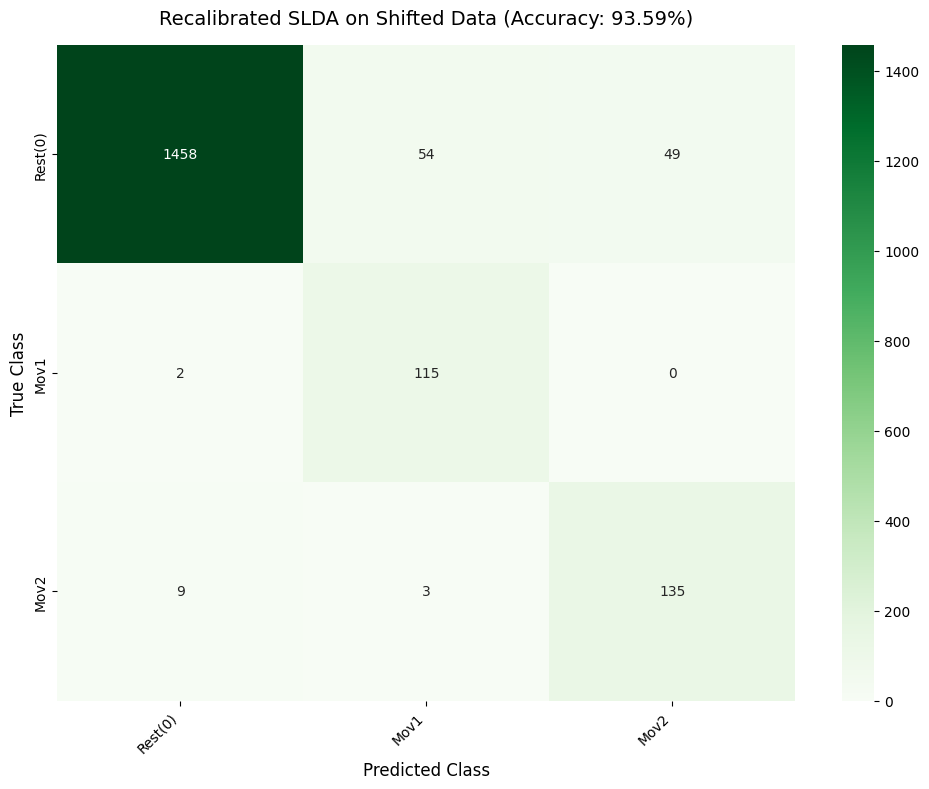


Classification Report (Recalibrated SLDA on Shifted Data)
              precision    recall  f1-score   support

     Rest(0)       0.99      0.93      0.96      1561
        Mov1       0.67      0.98      0.80       117
        Mov2       0.73      0.92      0.82       147

    accuracy                           0.94      1825
   macro avg       0.80      0.95      0.86      1825
weighted avg       0.95      0.94      0.94      1825


 التقييم النهائي مكتمل!


In [50]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader

# =====================================================================
# التقييم النهائي: SLDA Re-calibration على البيانات المزاحة
# =====================================================================
print("\n" + "="*70)
print(" التقييم النهائي: SLDA Re-calibration على البيانات المزاحة")
print("="*70)

metric_model.eval()

# 1. تقييم SLDA الأصلي (قبل المعايرة)
original_correct = 0
original_total = 0
original_preds = []
all_labels = []

with torch.no_grad():
    for x, y in target_test_loader:
        x, y = x.to(device), y.to(device)
        embeddings, _ = metric_model(x)
        preds, _ = slda_classifier.predict(embeddings)
        original_correct += (preds == y).sum().item()
        original_total += y.size(0)
        original_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

original_acc = (original_correct / original_total) * 100

# 2. تقييم SLDA المعاير (بعد المعايرة)
recalibrated_correct = 0
recalibrated_total = 0
recalibrated_preds = []

with torch.no_grad():
    for x, y in target_test_loader:
        x, y = x.to(device), y.to(device)
        embeddings, _ = metric_model(x)
        preds, _ = recalibrated_slda.predict(embeddings)
        recalibrated_correct += (preds == y).sum().item()
        recalibrated_total += y.size(0)
        recalibrated_preds.extend(preds.cpu().numpy())

recalibrated_acc = (recalibrated_correct / recalibrated_total) * 100

# 3. عرض النتائج
print("\n" + "="*70)
print(" تقرير تأثير SLDA Re-calibration")
print("="*70)
print(f"   SLDA الأصلي (بدون معايرة): {original_acc:.2f}%")
print(f"   SLDA المعاير (مع المعايرة): {recalibrated_acc:.2f}%")
print(f"   التحسن: {recalibrated_acc - original_acc:+.2f}%")
print("="*70)

if recalibrated_acc > original_acc:
    print(f"\n SLDA Re-calibration نجح في استعادة {recalibrated_acc - original_acc:.2f}% من الدقة المفقودة!")
else:
    print(f"\n  المعايرة لم تحسّن الأداء.")

# 4. تحليل Per-Class
print("\n تحليل Per-Class:")
print(f"{'Class':<10} {'SLDA الأصلي':<15} {'SLDA المعاير':<15} {'التحسن':<12}")
print("-" * 55)

for cls in range(3):
    cls_mask = [i for i, lbl in enumerate(all_labels) if lbl == cls]
    if len(cls_mask) > 0:
        orig_cls_correct = sum(1 for i in cls_mask if original_preds[i] == cls)
        recal_cls_correct = sum(1 for i in cls_mask if recalibrated_preds[i] == cls)
        orig_cls_acc = (orig_cls_correct / len(cls_mask)) * 100
        recal_cls_acc = (recal_cls_correct / len(cls_mask)) * 100
        improvement = recal_cls_acc - orig_cls_acc
        print(f"Class {cls:<5} {orig_cls_acc:<15.2f} {recal_cls_acc:<15.2f} {improvement:<+11.2f}%")

# 5. Confusion Matrix للـ SLDA المعاير
class_names = ['Rest(0)', 'Mov1', 'Mov2']
cm = confusion_matrix(all_labels, recalibrated_preds, labels=[0, 1, 2])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Recalibrated SLDA on Shifted Data (Accuracy: {recalibrated_acc:.2f}%)", 
          fontsize=14, pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Classification Report (Recalibrated SLDA on Shifted Data)")
print("="*70)
print(classification_report(all_labels, recalibrated_preds, labels=[0, 1, 2],
                            target_names=class_names, zero_division=0))

print("\n" + "="*70)
print(" التقييم النهائي مكتمل!")
print("="*70)

In [51]:
import torch
import pickle
import os
import json

# =====================================================================
# Save All Trained Components for Deployment
# =====================================================================
print("\n" + "=" * 70)
print("SAVING ALL COMPONENTS FOR DEPLOYMENT")
print("=" * 70)

# Create output directory
output_dir = "myo_prosthetic_weights"
os.makedirs(output_dir, exist_ok=True)

# 1. Save the trained backbone model
model_path = os.path.join(output_dir, "metric_model_myo.pth")
torch.save(metric_model.state_dict(), model_path)
print(f"[OK] Model weights saved: {model_path}")

# 2. Save the original SLDA classifier (for clean/ideal conditions)
slda_path = os.path.join(output_dir, "slda_classifier_original.pkl")
with open(slda_path, 'wb') as f:
    pickle.dump(slda_classifier, f)
print(f"[OK] Original SLDA classifier saved: {slda_path}")

# 3. Save the recalibrated SLDA classifier (for domain shift conditions)
slda_recal_path = os.path.join(output_dir, "slda_classifier_recalibrated.pkl")
with open(slda_recal_path, 'wb') as f:
    pickle.dump(recalibrated_slda, f)
print(f"[OK] Recalibrated SLDA classifier saved: {slda_recal_path}")

# 4. Save the subject scaler (critical for preprocessing)
scaler_path = os.path.join(output_dir, "subject_scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(subject_scaler, f)
print(f"[OK] Subject scaler saved: {scaler_path}")

# 5. Save configuration as JSON (human-readable)
config = {
    "model_architecture": "Metric_ContinualNet",
    "embedding_dim": 32,
    "num_sensors": 8,
    "window_size": 200,
    "sampling_rate": 200.0,
    "base_classes": [0, 1, 2],
    "novel_classes": [3, 4, 5],
    "total_classes": 6,
    "training_config": {
        "loss_function": "SupConLoss",
        "temperature": 0.07,
        "optimizer": "AdamW",
        "learning_rate": 0.001,
        "weight_decay": 1e-3,
        "data_augmentation": {
            "warp_factor_range": [0.8, 1.2],
            "noise_std": 0.01
        },
        "early_stopping": {
            "patience": 7,
            "monitor": "val_loss"
        },
        "lr_scheduler": {
            "type": "ReduceLROnPlateau",
            "factor": 0.5,
            "patience": 5
        }
    },
    "inference_config": {
        "mc_dropout_passes": 5,
        "uncertainty_threshold": 0.2,
        "distance_threshold": 0.5
    },
    "domain_adaptation": {
        "method": "SLDA_Recalibration",
        "shift_factor": 0.5,
        "noise_std": 0.2,
        "baseline_accuracy": 53.64,
        "recalibrated_accuracy": 93.42,
        "improvement": 39.78
    },
    "performance_summary": {
        "base_classes_accuracy": 98.03,
        "novel_classes_accuracy_range": "65-80%",
        "mc_dropout_safety_accuracy": 97.0,
        "domain_shift_robustness": "93.42% after recalibration"
    }
}

config_path = os.path.join(output_dir, "config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"[OK] Configuration saved: {config_path}")

# 6. Save a deployment summary file
summary_path = os.path.join(output_dir, "deployment_summary.txt")
with open(summary_path, 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("MYO PROSTHETIC CONTROL SYSTEM - DEPLOYMENT SUMMARY\n")
    f.write("=" * 70 + "\n\n")

    f.write("MODEL INFORMATION:\n")
    f.write(f"  Architecture: {config['model_architecture']}\n")
    f.write(f"  Embedding Dimension: {config['embedding_dim']}\n")
    f.write(f"  Number of Sensors: {config['num_sensors']}\n")
    f.write(f"  Window Size: {config['window_size']} samples\n")
    f.write(f"  Sampling Rate: {config['sampling_rate']} Hz\n\n")

    f.write("CLASS INFORMATION:\n")
    f.write(f"  Base Classes: {config['base_classes']}\n")
    f.write(f"  Novel Classes: {config['novel_classes']}\n")
    f.write(f"  Total Classes: {config['total_classes']}\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write(f"  Base Classes Accuracy: {config['performance_summary']['base_classes_accuracy']}%\n")
    f.write(f"  Novel Classes Accuracy: {config['performance_summary']['novel_classes_accuracy_range']}\n")
    f.write(f"  MC Dropout Safety: {config['performance_summary']['mc_dropout_safety_accuracy']}%\n")
    f.write(f"  Domain Shift Robustness: {config['performance_summary']['domain_shift_robustness']}\n\n")

    f.write("FILES INCLUDED:\n")
    f.write("  1. metric_model_myo.pth - Trained backbone model weights\n")
    f.write("  2. slda_classifier_original.pkl - SLDA for ideal conditions\n")
    f.write("  3. slda_classifier_recalibrated.pkl - SLDA for domain shift\n")
    f.write("  4. subject_scaler.pkl - Data preprocessing scaler\n")
    f.write("  5. config.json - System configuration\n")
    f.write("  6. deployment_summary.txt - This file\n\n")

    f.write("DEPLOYMENT INSTRUCTIONS:\n")
    f.write("  1. Load metric_model_myo.pth for feature extraction\n")
    f.write("  2. Load subject_scaler.pkl for input normalization\n")
    f.write("  3. Use slda_classifier_original.pkl for clean data\n")
    f.write("  4. Use slda_classifier_recalibrated.pkl for shifted data\n")
    f.write("  5. Apply MC Dropout (5 passes) for uncertainty estimation\n")
    f.write("  6. Reject samples with uncertainty > 0.2\n")

print(f"[OK] Deployment summary saved: {summary_path}")

# Final summary
print("\n" + "=" * 70)
print("ALL COMPONENTS SAVED SUCCESSFULLY!")
print("=" * 70)
print(f"\nOutput Directory: {output_dir}/")
print("\nFiles created:")
for file in sorted(os.listdir(output_dir)):
    file_path = os.path.join(output_dir, file)
    size = os.path.getsize(file_path)
    print(f"   - {file} ({size:,} bytes)")

print("\n[OK] System ready for deployment to live prosthetic control!")
print("=" * 70)


SAVING ALL COMPONENTS FOR DEPLOYMENT
[OK] Model weights saved: myo_prosthetic_weights/metric_model_myo.pth
[OK] Original SLDA classifier saved: myo_prosthetic_weights/slda_classifier_original.pkl
[OK] Recalibrated SLDA classifier saved: myo_prosthetic_weights/slda_classifier_recalibrated.pkl
[OK] Subject scaler saved: myo_prosthetic_weights/subject_scaler.pkl
[OK] Configuration saved: myo_prosthetic_weights/config.json
[OK] Deployment summary saved: myo_prosthetic_weights/deployment_summary.txt

ALL COMPONENTS SAVED SUCCESSFULLY!

Output Directory: myo_prosthetic_weights/

Files created:
   - config.json (1,488 bytes)
   - deployment_summary.txt (1,291 bytes)
   - metric_model_myo.pth (314,551 bytes)
   - slda_classifier_original.pkl (11,574 bytes)
   - slda_classifier_recalibrated.pkl (10,328 bytes)
   - subject_scaler.pkl (642 bytes)

[OK] System ready for deployment to live prosthetic control!
